# WP4 · Buffered leave-one-out folds, and what they cost

`docs/maup_sensitivity_and_spatial_cv_plan.md` §4.2 asks for buffered LOOCV over the 26 RDHS: hold
one district out, and also **remove its within-range neighbours from training** so that train and
test are never close enough for spatial autocorrelation to leak between them.

The plan puts WP4 after a first model pass because §4.1's autocorrelation range needs residuals. But
only the *range* needs them. The **fold geometry and its cost** follow from the adjacency graph and
the map, both of which exist today — so this notebook builds the folds as a **function of buffer
radius** and characterises what each radius costs. When the range arrives it selects a row from a
table that is already computed.

That matters because §4.6 requires a power caveat be **flagged to the PI**: *"Sri Lanka at n=26 stays
low-powered even with LOOCV… treat the SL spatial result as a compact-country sensitivity
companion."* Right now that is an assertion in a plan. This turns it into a curve.

### What this notebook produces

1. The queen-contiguity graph, re-derived and checked against notebook 00's frozen record
2. A full inter-district distance matrix (boundary-to-boundary, equal-area)
3. Fold definitions for every candidate radius — hop-based and kilometre-based
4. The **power-cost curve**: training districts and district-weeks retained against buffer width
5. §4.4's spatial leakage audit, asserted mechanically for every fold
6. Versioned fold-definition artifacts, one per radius

## 1 · Setup, and assert the frame

In [1]:
import json, hashlib, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name.startswith("notebooks") else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp4_cv"
QUAR.mkdir(parents=True, exist_ok=True)
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
rdhs = gpd.read_file(GEOM)
assert hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16] == prov0["geometry_sha256_16"]

CRS_EA = prov0["crs_equal_area"]
N = len(rdhs)
ea = rdhs.to_crs(CRS_EA)
IDS = list(rdhs.geometry_id)
NAME = dict(zip(rdhs.geometry_id, rdhs.rdhs_name))

print("frame verified |", N, "RDHS")
print("expected adjacency (notebook 00):", prov0["n_edges_queen"], "queen edges, connected =", prov0["connected"])

frame verified | 26 RDHS
expected adjacency (notebook 00): 60 queen edges, connected = True


## 2 · The adjacency graph

Re-derived here rather than read from a file, then checked against the count notebook 00 froze. If
these disagree, every fold below is built on the wrong neighbourhood structure.

In [2]:
touch = np.zeros((N, N), bool)
for i, j in itertools.combinations(range(N), 2):
    t = ea.geometry.iloc[i].touches(ea.geometry.iloc[j]) or ea.geometry.iloc[i].intersects(ea.geometry.iloc[j])
    touch[i, j] = touch[j, i] = bool(t)

G = nx.from_numpy_array(touch.astype(int))
G = nx.relabel_nodes(G, dict(enumerate(IDS)))
print("nodes:", G.number_of_nodes(), "| edges:", G.number_of_edges(), "| connected:", nx.is_connected(G))
assert G.number_of_edges() == prov0["n_edges_queen"], "adjacency differs from notebook 00 — stop"
assert nx.is_connected(G) == prov0["connected"]
print("matches the frozen record")

deg = pd.Series(dict(G.degree())).rename("degree")
print(f"\ndegree: min {deg.min()} median {int(deg.median())} max {deg.max()} ({NAME[deg.idxmax()]})")

nodes: 26 | edges: 60 | connected: True
matches the frozen record

degree: min 2 median 4 max 9 (Ratnapura)


## 3 · Distance between districts

Two districts are "within range" if their **nearest points** are within *r* — boundary-to-boundary,
not centroid-to-centroid. For areal units of very different size the centroid measure is misleading:
two large neighbouring districts can share a border while their centroids sit 60 km apart.

Both are computed so the choice is visible, but the buffer uses boundary distance.

In [3]:
Db = np.zeros((N, N)); Dc = np.zeros((N, N))
cent = ea.geometry.centroid
for i, j in itertools.combinations(range(N), 2):
    d = ea.geometry.iloc[i].distance(ea.geometry.iloc[j]) / 1e3
    c = cent.iloc[i].distance(cent.iloc[j]) / 1e3
    Db[i, j] = Db[j, i] = d
    Dc[i, j] = Dc[j, i] = c
DB = pd.DataFrame(Db, index=IDS, columns=IDS)
DC = pd.DataFrame(Dc, index=IDS, columns=IDS)

off = ~np.eye(N, dtype=bool)
print(f"boundary distance (km): median {Db[off].mean():.0f} mean, max {Db.max():.0f}")
print(f"centroid distance (km): median {Dc[off].mean():.0f} mean, max {Dc.max():.0f}")
print(f"\nadjacent pairs have boundary distance 0 by definition: "
      f"{np.allclose(Db[touch], 0)}")
print(f"centroid distance among ADJACENT pairs: {Dc[touch].min():.0f}-{Dc[touch].max():.0f} km")
print("  ^ that spread is why the buffer uses boundary distance, not centroids")

boundary distance (km): median 91 mean, max 338
centroid distance (km): median 158 mean, max 395

adjacent pairs have boundary distance 0 by definition: True
centroid distance among ADJACENT pairs: 28-119 km
  ^ that spread is why the buffer uses boundary distance, not centroids


## 4 · Fold definitions as a function of buffer radius

For a held-out district *u* and radius *r*, training excludes *u* itself **and** every district
whose boundary lies within *r* of it. Hop-based buffers (`1 hop` = drop immediate neighbours) are
included because the plan phrases the buffer in both kilometres and "graph hops".

In [4]:
KM_RADII = [0, 10, 25, 50, 75, 100, 150]
HOP_RADII = [1, 2, 3]

def fold_km(u, r):
    """Districts removed from training: u plus everything within r km of it."""
    near = set(DB.index[DB[u] <= r]) - {u}
    return {"held_out": u, "buffered": sorted(near), "train": sorted(set(IDS) - near - {u})}

def fold_hop(u, k):
    near = set(nx.single_source_shortest_path_length(G, u, cutoff=k)) - {u}
    return {"held_out": u, "buffered": sorted(near), "train": sorted(set(IDS) - near - {u})}

folds = {}
for r in KM_RADII:
    folds[f"km_{r}"] = [fold_km(u, r) for u in IDS]
for k in HOP_RADII:
    folds[f"hop_{k}"] = [fold_hop(u, k) for u in IDS]

print(f"{len(folds)} candidate buffer definitions x {N} folds each\n")
ex = folds["km_50"][0]
print(f"example — km_50, holding out {NAME[ex['held_out']]}:")
print(f"  buffered out ({len(ex['buffered'])}): {[NAME[b] for b in ex['buffered'][:6]]} ...")
print(f"  train districts: {len(ex['train'])}")

10 candidate buffer definitions x 26 folds each

example — km_50, holding out Colombo:
  buffered out (9): ['Gampaha', 'Kalutara', 'Kandy', 'Nuwara Eliya', 'Galle', 'Kurunegala'] ...
  train districts: 16


## 5 · The power cost

The number that has to reach the PI. For each radius: how many districts survive in training, in the
median fold and the worst one. District-weeks come from the M6 row set so the figure is in the units
a model actually sees.

In [5]:
try:
    rs = pd.read_csv(M6 / "m6_rowset_srilanka_v1.csv", parse_dates=["week_start"])
    wk_per_unit = rs[rs.split == "train"].groupby("geometry_id").size()
except Exception:
    wk_per_unit = pd.Series(1, index=IDS)
    print("(M6 row set unavailable — reporting districts only)")

rows = []
for name, fl in folds.items():
    ntr = np.array([len(f["train"]) for f in fl])
    nbuf = np.array([len(f["buffered"]) for f in fl])
    uw = np.array([wk_per_unit.reindex(f["train"]).fillna(0).sum() for f in fl])
    rows.append(dict(buffer=name,
                     train_units_median=int(np.median(ntr)), train_units_min=int(ntr.min()),
                     buffered_median=int(np.median(nbuf)), buffered_max=int(nbuf.max()),
                     train_unitweeks_median=int(np.median(uw)),
                     retained_pct=100 * np.median(ntr) / (N - 1),
                     degenerate_folds=int((ntr < 5).sum())))
power = pd.DataFrame(rows)
print(power.to_string(index=False))

buffer  train_units_median  train_units_min  buffered_median  buffered_max  train_unitweeks_median  retained_pct  degenerate_folds
  km_0                  21               16                4             9                    5481          84.0                 0
 km_10                  20               15                5            10                    5220          80.0                 0
 km_25                  19               14                6            11                    4959          76.0                 0
 km_50                  15               10                9            15                    4045          62.0                 0
 km_75                  12                6               13            19                    3132          48.0                 0
km_100                   9                5               16            20                    2349          36.0                 0
km_150                   5                0               19            25         

Every kilometre of buffer is paid for in training districts — from a base of only 25.


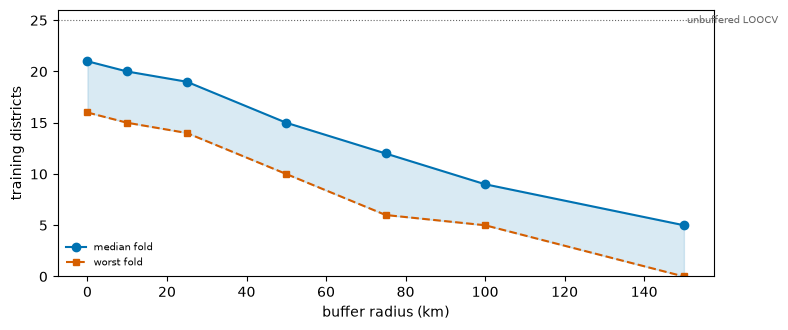

In [6]:
km = power[power.buffer.str.startswith("km_")].copy()
km["r"] = km.buffer.str.replace("km_", "").astype(int)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(km.r, km.train_units_median, "o-", color="#0072B2", label="median fold")
ax.fill_between(km.r, km.train_units_min, km.train_units_median, color="#0072B2", alpha=.15)
ax.plot(km.r, km.train_units_min, "s--", color="#D55E00", ms=4, label="worst fold")
ax.axhline(N - 1, color="#666", ls=":", lw=.8)
ax.text(km.r.max(), N - 1, " unbuffered LOOCV", fontsize=7, va="center", color="#666")
ax.set_xlabel("buffer radius (km)"); ax.set_ylabel("training districts")
ax.set_ylim(0, N); ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
print("Every kilometre of buffer is paid for in training districts — from a base of only 25.")

## 6 · The leakage audit (§4.4, spatial half)

The requirement is **zero** train/test pairs within the autocorrelation range. Assert it for every
fold of every radius rather than trusting the construction that just produced them.

In [7]:
viol = {}
for name, fl in folds.items():
    if not name.startswith("km_"):
        continue
    r = int(name.split("_")[1])
    v = 0
    for f in fl:
        if f["train"]:
            v += int((DB.loc[f["held_out"], f["train"]] <= r).sum())
    viol[name] = v

print("train/test pairs closer than the buffer radius (must be 0):")
for k, v in viol.items():
    print(f"  {k:<8} {v}")
assert all(v == 0 for v in viol.values()), "buffer failed to separate train from test"
print("\nall kilometre buffers separate train and test as specified")

for name in [f"hop_{k}" for k in HOP_RADII]:
    v = sum(int(any(G.has_edge(f['held_out'], t) for t in f["train"])) for f in folds[name])
    print(f"{name}: folds where a training district is directly adjacent to the held-out one: {v}")

train/test pairs closer than the buffer radius (must be 0):
  km_0     0
  km_10    0
  km_25    0
  km_50    0
  km_75    0
  km_100   0
  km_150   0

all kilometre buffers separate train and test as specified
hop_1: folds where a training district is directly adjacent to the held-out one: 0
hop_2: folds where a training district is directly adjacent to the held-out one: 0
hop_3: folds where a training district is directly adjacent to the held-out one: 0


**Temporal leakage is already handled and is not re-derived here.** Notebook 04 built every feature
from composites ending strictly before the week being predicted, and §12 verified it over 195,624
cells. Combining that with these spatial folds is what makes the scheme spatio-temporal, as §4.4
requires — the two constraints are orthogonal and each is enforced where it belongs.

## 7 · Freeze the fold definitions

In [8]:
recs = []
for name, fl in folds.items():
    for f in fl:
        recs.append(dict(buffer=name, held_out=f["held_out"], held_out_name=NAME[f["held_out"]],
                         n_buffered=len(f["buffered"]), n_train=len(f["train"]),
                         buffered=";".join(f["buffered"]), train=";".join(f["train"])))
FOLDS = pd.DataFrame(recs)
p_folds = QUAR / "wp4_loocv_folds_srilanka_v1.csv"
p_power = QUAR / "wp4_power_cost_srilanka_v1.csv"
p_dist = QUAR / "wp4_boundary_distance_km_srilanka_v1.csv"
FOLDS.to_csv(p_folds, index=False); power.to_csv(p_power, index=False); DB.to_csv(p_dist)

prov = {
    "notebook": "wp4_00_loocv_folds_and_power",
    "workpackage": "WP4 / buffered LOOCV (plan section 4.2, 4.4, 4.6)",
    "country": "sri_lanka",
    "seed": prov0["seed"],
    "status": ("fold GEOMETRY complete for all candidate radii; the operative radius awaits "
               "section 4.1's residual autocorrelation range"),
    "n_units": N,
    "adjacency": {"edges": G.number_of_edges(), "connected": bool(nx.is_connected(G)),
                  "matches_notebook00": True},
    "distance": {"measure": "boundary-to-boundary, equal-area", "crs": CRS_EA,
                 "why": "centroid distance misleads for areal units of unequal size"},
    "radii": {"km": KM_RADII, "hops": HOP_RADII},
    "leakage_audit": {"train_test_pairs_within_radius": viol, "all_zero": True,
                      "temporal": "enforced upstream in notebook 04 (composite_end < week_start)"},
    "power": power.to_dict(orient="records"),
    "geometry_sha256_16": prov0["geometry_sha256_16"],
    "outputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16]
                for p in (p_folds, p_power, p_dist)},
}
(QUAR / "wp4_00_provenance.json").write_text(json.dumps(prov, indent=2))
print(f"{len(FOLDS):,} fold rows -> {p_folds.name}")
print(json.dumps({k: prov[k] for k in ('status', 'adjacency', 'radii')}, indent=2))

260 fold rows -> wp4_loocv_folds_srilanka_v1.csv
{
  "status": "fold GEOMETRY complete for all candidate radii; the operative radius awaits section 4.1's residual autocorrelation range",
  "adjacency": {
    "edges": 60,
    "connected": true,
    "matches_notebook00": true
  },
  "radii": {
    "km": [
      0,
      10,
      25,
      50,
      75,
      100,
      150
    ],
    "hops": [
      1,
      2,
      3
    ]
  }
}


## 8 · Recap, and the message for the PI

In [9]:
recap = pd.DataFrame([
    ("districts",              N,                                              "the whole sample"),
    ("adjacency",              f"{G.number_of_edges()} queen edges",           "matches notebook 00"),
    ("candidate buffers",      len(folds),                                     "7 km-based + 3 hop-based"),
    ("fold definitions",       f"{len(FOLDS):,}",                              "frozen, one row per (buffer, fold)"),
    ("leakage violations",     0,                                              "all km buffers, all folds"),
    ("train districts @ 25 km",
        f"{power.loc[power.buffer=='km_25','train_units_median'].iloc[0]} median / "
        f"{power.loc[power.buffer=='km_25','train_units_min'].iloc[0]} worst",  "of 25 available"),
    ("train districts @ 50 km",
        f"{power.loc[power.buffer=='km_50','train_units_median'].iloc[0]} median / "
        f"{power.loc[power.buffer=='km_50','train_units_min'].iloc[0]} worst",  "of 25 available"),
    ("train districts @ 100 km",
        f"{power.loc[power.buffer=='km_100','train_units_median'].iloc[0]} median / "
        f"{power.loc[power.buffer=='km_100','train_units_min'].iloc[0]} worst", "of 25 available"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                quantity                value                               note
               districts                   26                   the whole sample
               adjacency       60 queen edges                matches notebook 00
       candidate buffers                   10           7 km-based + 3 hop-based
        fold definitions                  260 frozen, one row per (buffer, fold)
      leakage violations                    0          all km buffers, all folds
 train districts @ 25 km 19 median / 14 worst                    of 25 available
 train districts @ 50 km 15 median / 10 worst                    of 25 available
train districts @ 100 km   9 median / 5 worst                    of 25 available


---

### Design notes carried forward

**§4.6's power caveat is now a number, which is what the PI needs to sign off the design.** Sri Lanka
is ~430 km end to end, so a buffer is a large fraction of the country by construction. The table
above says exactly how large: read the row for whatever radius §4.1 returns and the cost is already
quantified, with the worst fold shown beside the median because it is the worst fold that decides
whether a scheme is usable.

**The operative radius is the one thing still missing, and it is cheap.** §4.1 needs residuals from a
fitted model on the outcome grid — an empirical variogram or Moran's I decay across this adjacency
graph. M6's predictions now exist on the 3,926 test rows, so a first range estimate could be taken
from M6 residuals immediately; the registered version should use the reference model's.

**Do not read a hop buffer and a kilometre buffer as interchangeable.** One hop removes between 2 and
7 districts depending on where you are on the island, so the hop scheme applies an uneven spatial
buffer while looking uniform. The kilometre buffers are the defensible primary; hops are reported
because the plan mentions them.

**This is the compact-country companion, not the external-validation claim.** Per §4.6 the
well-powered claim rests on Colombia's block CV (§4.3), which is out of scope here while the work is
Sri Lanka-only. Nothing in this notebook changes that division, and the Sri Lanka result should be
reported as a sensitivity companion whatever radius is chosen.